# 02 — Partición temporal de entrenamiento, validación y prueba

En este notebook definimos cómo se dividirán las transacciones etiquetadas para las etapas posteriores. La decisión no se reduce a escoger porcentajes: necesitamos representar el orden real de llegada, reservar un periodo final que no influya en el desarrollo y dejar intervalos de separación que reduzcan la dependencia entre observaciones cercanas.

Nuestro objetivo es comparar varias duraciones de gap, comprobar cuántas transacciones y fraudes conserva cada alternativa y congelar una sola asignación mediante `TransactionID`. No imputamos, codificamos ni entrenamos modelos en esta etapa.

## 1. Preparación

Solo cargamos las columnas necesarias para decidir y describir la partición. Incluimos algunos identificadores de tarjeta, dirección y correo para medir cuántos valores aparecen por primera vez en periodos futuros. La lógica crítica de asignación está en `fraud_cost.split`, donde puede probarse sin depender del notebook.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fraud_cost.split import (
    create_temporal_split,
    summarize_temporal_split,
    validate_temporal_split,
)


def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("No encontramos la raíz del proyecto")


PROJECT_ROOT = find_project_root()
TRANSACTION_PATH = PROJECT_ROOT / "data" / "raw" / "train_transaction.csv"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

for directory in (INTERIM_DIR, RESULTS_TABLES, RESULTS_FIGURES):
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
print(f"Datos: {TRANSACTION_PATH}")

Datos: C:\Users\Milton Cuervo\Documents\IEEE-CIS Fraud Detection-PI2\data\raw\train_transaction.csv


## 2. Rango temporal y variables mínimas

`TransactionDT` no es una fecha calendario, sino un contador de segundos desde un origen no publicado. Trabajaremos con días relativos al inicio. Esto es suficiente para ordenar observaciones y definir ventanas, pero no para asignar nombres de meses o fechas que el dataset no proporciona.

In [2]:
usecols = [
    "TransactionID", "TransactionDT", "TransactionAmt", "isFraud",
    "card1", "card2", "card3", "card5", "addr1", "addr2", "P_emaildomain",
]
df = pd.read_csv(TRANSACTION_PATH, usecols=usecols)
df = df.sort_values(["TransactionDT", "TransactionID"]).reset_index(drop=True)

time_start = df["TransactionDT"].min()
time_end = df["TransactionDT"].max()
duration_days = (time_end - time_start) / 86_400

print(f"Transacciones: {len(df):,}")
print(f"Fraudes: {df['isFraud'].sum():,} ({df['isFraud'].mean():.3%})")
print(f"Duración relativa: {duration_days:.1f} días")
print(f"Orden temporal creciente: {df['TransactionDT'].is_monotonic_increasing}")

Transacciones: 590,540
Fraudes: 20,663 (3.499%)
Duración relativa: 182.0 días
Orden temporal creciente: True


## 3. Configuraciones candidatas

Fijamos el final de entrenamiento en 60% del rango temporal y el final de validación en 80%. Los gaps comienzan después de cada límite y consumen parte del periodo siguiente. Comparamos 1, 3 y 7 días de separación.

No escogemos el gap por maximizar una métrica, porque todavía no existe un modelo. Revisamos el costo en datos: tamaño de cada bloque, cantidad de fraudes, prevalencia y monto mediano. Una alternativa solo es viable si deja suficientes fraudes para seleccionar/calibrar en validación y para realizar la evaluación final.

In [3]:
candidate_summaries = []

for gap_days in (1, 3, 7):
    candidate_split = create_temporal_split(df, gap_days=gap_days)
    candidate_summary = summarize_temporal_split(df, candidate_split)
    candidate_summary.insert(0, "gap_dias", gap_days)
    candidate_summaries.append(candidate_summary.reset_index())

candidates = pd.concat(candidate_summaries, ignore_index=True)
display(candidates[[
    "gap_dias", "split", "transacciones", "fraudes", "tasa_fraude",
    "monto_mediano", "dia_inicio_relativo", "dia_fin_relativo",
]])
candidates.to_csv(RESULTS_TABLES / "particion_candidatos.csv", index=False)

,gap_dias,split,transacciones,fraudes,tasa_fraude,monto_mediano,dia_inicio_relativo,dia_fin_relativo
0,1,train,380815,13011,0.034166,69.280,0.000000,109.199282
1,1,gap_1,2970,110,0.037037,67.950,109.199884,110.199491
2,1,validation,102118,3980,0.038975,67.950,110.200521,145.599236
3,1,gap_2,2944,91,0.030910,75.000,145.599757,146.599271
4,1,test,101693,3471,0.034132,68.500,146.599664,181.999201
5,3,train,380815,13011,0.034166,69.280,0.000000,109.199282
6,3,gap_1,9325,372,0.039893,67.950,109.199884,112.199398
7,3,validation,95763,3718,0.038825,67.950,112.199745,145.599236
8,3,gap_2,8498,250,0.029419,75.000,145.599757,148.598866
9,3,test,96139,3312,0.034450,68.500,148.599387,181.999201


## 4. Elección del gap

Elegimos un gap de **7 días**. Es la alternativa más conservadora de las tres y cubre un ciclo semanal completo en el tiempo relativo. Aun así, conserva más de 3.000 fraudes en validación y cerca de 3.000 en prueba, cantidades suficientes para comparar calibración y reglas económicas sin depender de unos pocos positivos.

Esta semana de separación no proviene como valor obligatorio de Dal Pozzolo et al. La referencia respalda una evaluación cronológica que reconozca no estacionariedad y retraso de etiquetas; la duración concreta es una decisión del proyecto basada en el rango de IEEE-CIS y en el costo observado de excluir los gaps.

In [4]:
GAP_DAYS = 7
split = create_temporal_split(df, gap_days=GAP_DAYS)
validate_temporal_split(df, split)

split_summary = summarize_temporal_split(df, split)
display(split_summary)
split_summary.to_csv(RESULTS_TABLES / "particion_resumen.csv")

,transacciones,fraudes,tasa_fraude,monto_mediano,monto_total,tiempo_inicio,tiempo_fin,dia_inicio_relativo,dia_fin_relativo
split,,,,,,,,,
train,380815,13011,0.034166,69.280,5.119246e+07,86400,9521218,0.000000,109.199282
gap_1,20995,1015,0.048345,67.791,2.828432e+06,9521270,10125995,109.199884,116.199016
validation,84093,3075,0.036567,67.950,1.131779e+07,10126067,12666174,116.199850,145.599236
gap_2,20404,602,0.029504,72.150,2.835907e+06,12666219,13270942,145.599757,152.598866
test,84233,2960,0.035141,68.500,1.156436e+07,13270993,15811131,152.599456,181.999201


## 5. Comprobaciones de la partición definitiva

Antes de guardarla verificamos cuatro invariantes: todas las transacciones tienen un bloque, ningún `TransactionID` se repite, los bloques aparecen en orden estricto y validación/test contienen fraudes. Estas comprobaciones son más importantes que confiar visualmente en los límites.

In [5]:
assert df["TransactionID"].is_unique
assert len(split) == len(df)
assert split.notna().all()
assert split[split.eq("validation")].size > 0
assert split[split.eq("test")].size > 0
assert df.loc[split.eq("validation"), "isFraud"].sum() > 0
assert df.loc[split.eq("test"), "isFraud"].sum() > 0

checks = pd.Series({
    "transacciones_asignadas": len(split),
    "transacciones_sin_bloque": int(split.isna().sum()),
    "transaction_id_duplicados": int(df["TransactionID"].duplicated().sum()),
    "fraudes_validacion": int(df.loc[split.eq("validation"), "isFraud"].sum()),
    "fraudes_test": int(df.loc[split.eq("test"), "isFraud"].sum()),
}, name="resultado")
display(checks.to_frame())

,resultado
transacciones_asignadas,590540
transacciones_sin_bloque,0
transaction_id_duplicados,0
fraudes_validacion,3075
fraudes_test,2960


## 6. Visualización de tamaños y prevalencia

La figura permite ver simultáneamente cuánto ocupa cada bloque y cómo cambia la tasa de fraude. Los gaps se muestran porque forman parte de la decisión, pero no se utilizarán para ajustar modelos, calibradores ni hiperparámetros.

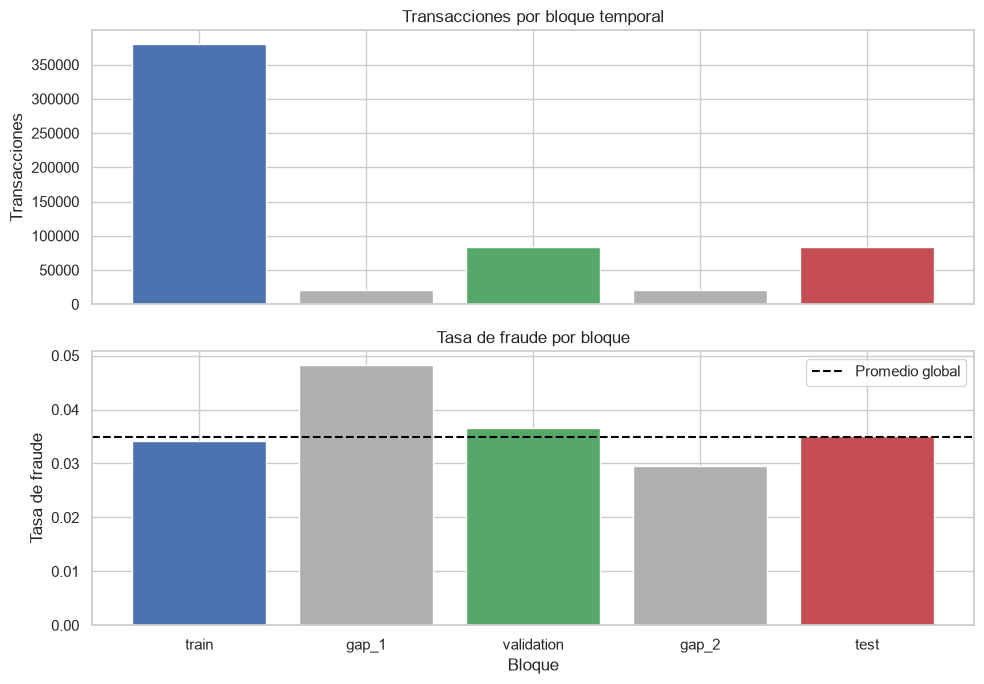

In [6]:
plot_summary = split_summary.reset_index()
colors = {
    "train": "#4C72B0", "gap_1": "#B0B0B0", "validation": "#55A868",
    "gap_2": "#B0B0B0", "test": "#C44E52",
}

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].bar(
    plot_summary["split"], plot_summary["transacciones"],
    color=[colors[label] for label in plot_summary["split"]],
)
axes[0].set(title="Transacciones por bloque temporal", ylabel="Transacciones")
axes[1].bar(
    plot_summary["split"], plot_summary["tasa_fraude"],
    color=[colors[label] for label in plot_summary["split"]],
)
axes[1].axhline(df["isFraud"].mean(), color="black", linestyle="--", label="Promedio global")
axes[1].set(title="Tasa de fraude por bloque", ylabel="Tasa de fraude", xlabel="Bloque")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS_FIGURES / "particion_resumen.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Valores que aparecen por primera vez en el futuro

Una evaluación futura también debe enfrentar categorías no observadas durante entrenamiento. Construimos una clave de tarjeta con `card1`, `card2`, `card3` y `card5`, y revisamos junto con correo y dirección qué proporción de validación/test contiene valores nuevos respecto a train.

Este análisis no elimina esas observaciones. Su función es anticipar que los codificadores deberán manejar categorías desconocidas sin fallar ni aprender información de los periodos futuros.

In [7]:
def combine_key(frame, columns):
    return frame[columns].astype("string").fillna("<NA>").agg("|".join, axis=1)


entity_keys = {
    "tarjeta_compuesta": combine_key(df, ["card1", "card2", "card3", "card5"]),
    "direccion_compuesta": combine_key(df, ["addr1", "addr2"]),
    "dominio_correo": df["P_emaildomain"].astype("string").fillna("<AUSENTE>"),
}

novelty_rows = []
train_mask = split.eq("train")
for variable, values in entity_keys.items():
    known = set(values[train_mask])
    for block in ("validation", "test"):
        block_mask = split.eq(block)
        unseen = ~values[block_mask].isin(known)
        novelty_rows.append({
            "variable": variable,
            "bloque": block,
            "observaciones": int(block_mask.sum()),
            "observaciones_no_vistas": int(unseen.sum()),
            "proporcion_no_vista": unseen.mean(),
        })

novelty = pd.DataFrame(novelty_rows)
display(novelty)
novelty.to_csv(RESULTS_TABLES / "particion_categorias_no_vistas.csv", index=False)

,variable,bloque,observaciones,observaciones_no_vistas,proporcion_no_vista
0,tarjeta_compuesta,validation,84093,1253,0.014900
1,tarjeta_compuesta,test,84233,1822,0.021630
2,direccion_compuesta,validation,84093,42,0.000499
3,direccion_compuesta,test,84233,24,0.000285
4,dominio_correo,validation,84093,0,0.000000
5,dominio_correo,test,84233,0,0.000000


## 8. Congelación del manifiesto

Guardamos únicamente `TransactionID`, `TransactionDT` y la etiqueta del bloque. No duplicamos las 434 variables ni generamos todavía datasets preparados. Los notebooks posteriores unirán este manifiesto por `TransactionID`, lo que garantiza que todo el equipo utilice exactamente la misma partición.

El archivo Parquet queda en `data/interim/` y no se sube a GitHub porque puede regenerarse. La tabla resumen y la figura sí se versionan como evidencia de la decisión.

In [8]:
manifest = df[["TransactionID", "TransactionDT"]].copy()
manifest["split"] = split
manifest_path = INTERIM_DIR / "split_manifest.parquet"
manifest.to_parquet(manifest_path, index=False)

verification = pd.read_parquet(manifest_path)
assert len(verification) == len(df)
assert verification["TransactionID"].is_unique
assert verification["split"].notna().all()

print(f"Manifiesto guardado en: {manifest_path}")
print(f"Tamaño: {manifest_path.stat().st_size / 1024**2:.2f} MB")

Manifiesto guardado en: C:\Users\Milton Cuervo\Documents\IEEE-CIS Fraud Detection-PI2\data\interim\split_manifest.parquet
Tamaño: 5.04 MB


## 9. Decisión final de esta etapa

La partición definitiva utiliza el primer 60% del rango temporal para entrenamiento, un gap de 7 días, el periodo restante hasta 80% para validación, un segundo gap de 7 días y el periodo final para prueba.

Los gaps quedan completamente excluidos del aprendizaje y de la evaluación. Validación podrá intervenir en selección de hiperparámetros y calibración; prueba se reservará para la comparación final de las tres estrategias de decisión. Ninguna transformación posterior podrá ajustarse con validación o test, salvo el calibrador cuando el protocolo establezca explícitamente su ajuste sobre validación.